# Readmission analysis

quick look at the data + first model

TODO: clean this up at some point

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns  # not sure if we need it yet

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.ml_utils import (
    load_and_clean, impute_numerics, encode_categoricals,
    train_test_split_by_patient, build_feature_matrix, scale_features,
    evaluate_model, plot_feature_importance, cross_validate_model,
    summarize_dataframe,
)


In [2]:
df = load_and_clean('../data/patients.csv')
print(df.shape)
df.head()

(2000, 12)


,patient_id,age,sex,bmi,num_prior_admissions,length_of_stay,diagnosis_code,hospital_id,lab_sodium,lab_creatinine,admission_date,readmission_30d
0,66930,61.0,M,33.412106,2,3,I10,H02,134.089147,1.657437,2023-02-23,0
1,56349,63.0,M,27.019882,0,8,F32.9,H01,133.419085,1.662463,2023-03-28,0
2,93036,25.0,other,26.176106,4,4,I10,H01,141.324683,1.160155,2024-04-24,0
3,17971,62.0,F,30.374959,1,3,N39.0,H02,139.781224,1.717052,NaT,0
4,28595,30.0,F,26.090192,0,3,E11.9,H05,138.102801,1.131046,2024-03-22,0


In [3]:
print(df.columns)
print(df.dtypes)
df.describe()

Index(['patient_id', 'age', 'sex', 'bmi', 'num_prior_admissions',
       'length_of_stay', 'diagnosis_code', 'hospital_id', 'lab_sodium',
       'lab_creatinine', 'admission_date', 'readmission_30d'],
      dtype='str')
patient_id                       int64
age                            float64
sex                                str
bmi                            float64
num_prior_admissions             int64
length_of_stay                   int64
diagnosis_code                     str
hospital_id                        str
lab_sodium                     float64
lab_creatinine                 float64
admission_date          datetime64[us]
readmission_30d                  int64
dtype: object


,patient_id,age,bmi,num_prior_admissions,length_of_stay,lab_sodium,lab_creatinine,admission_date,readmission_30d
count,2000.000000,1940.000000,1790.000000,2000.0000,2000.000000,1697.000000,1585.000000,1260,2000.000000
mean,55277.560000,55.932990,29.627081,1.5475,5.995000,139.073974,0.985123,2023-12-20 10:12:34.285714,0.199000
min,10110.000000,18.000000,1.200000,0.0000,1.000000,128.112237,-0.860225,2023-01-01 00:00:00,0.000000
25%,33091.750000,37.000000,23.518347,1.0000,3.000000,136.655741,0.723678,2023-06-28 00:00:00,0.000000
50%,55078.000000,56.000000,27.230124,1.0000,5.000000,139.123090,0.984526,2023-12-22 00:00:00,0.000000
75%,78191.750000,74.250000,31.155946,2.0000,8.000000,141.604554,1.266824,2024-06-09 06:00:00,0.000000
max,99985.000000,95.000000,400.000000,7.0000,24.000000,150.569243,2.635169,2024-11-30 00:00:00,1.000000
std,26057.191505,22.221717,30.382574,1.2456,3.474912,3.592531,0.419834,NaN,0.399348


look at nulls

In [4]:
df.isna().sum()
# print(df.isna().mean() * 100)   # kept in case we want % later


patient_id                0
age                      60
sex                      25
bmi                     210
num_prior_admissions      0
length_of_stay            0
diagnosis_code            0
hospital_id               0
lab_sodium              303
lab_creatinine          415
admission_date          740
readmission_30d           0
dtype: int64

In [5]:
# quick dedup
df = df.drop_duplicates()
print(df.shape)

(2000, 12)


In [6]:
# look at older patients
tmp = df[df['age'] > 47.3]
print(tmp.shape)
tmp.head()

(1192, 12)


,patient_id,age,sex,bmi,num_prior_admissions,length_of_stay,diagnosis_code,hospital_id,lab_sodium,lab_creatinine,admission_date,readmission_30d
0,66930,61.0,M,33.412106,2,3,I10,H02,134.089147,1.657437,2023-02-23,0
1,56349,63.0,M,27.019882,0,8,F32.9,H01,133.419085,1.662463,2023-03-28,0
3,17971,62.0,F,30.374959,1,3,N39.0,H02,139.781224,1.717052,NaT,0
5,96206,62.0,F,25.630098,0,7,J44.9,H02,136.948669,NaN,NaT,0
6,81306,90.0,M,33.204242,2,7,unknown,H01,139.632914,NaN,2023-04-28,0


In [7]:
# first pass preprocessing -- impute + encode + scale everything then split
df_v2 = df.copy()
df_v2 = impute_numerics(df_v2)          # mutates in place btw
df_v2 = encode_categoricals(df_v2)

X_all, y_all = build_feature_matrix(df_v2)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)      # <-- fit on ALL data
print(X_all_scaled.shape)

(2000, 29)


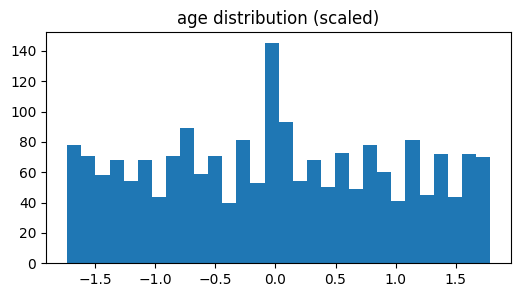

In [8]:
plt.figure(figsize=(6,3))
plt.hist(X_all_scaled[:, 0], bins=30)
plt.title('age distribution (scaled)')
plt.show()

ok let's train a model

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_all_scaled, y_all, test_size=0.2, random_state=0
)
print(X_train.shape, X_test.shape)

(1600, 29) (400, 29)


In [10]:
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)
print('train acc:', model.score(X_train, y_train))
print('test acc:', model.score(X_test, y_test))

train acc: 0.830625
test acc: 0.8475


In [11]:
res = evaluate_model(model, X_test, y_test)
print(res)

{'accuracy': 0.8475, 'roc_auc': 0.6047450553438577, 'confusion_matrix': array([[323,  11],
       [ 50,  16]])}


In [12]:
# --- old experiments, keep just in case ---
# model2 = LogisticRegression(C=0.1)
# model2.fit(X_train, y_train)
# print(model2.score(X_test, y_test))
# for c in [0.01, 0.1, 1, 10]:
#     m = LogisticRegression(C=c, max_iter=500)
#     m.fit(X_train, y_train)
#     print(c, m.score(X_test, y_test))
# print('--')
# df.groupby('hospital_id')['readmission_30d'].mean()
# df.groupby('diagnosis_code')['readmission_30d'].mean()


try a random forest now

In [13]:
# redo pre-processing for rf
df_final = load_and_clean('../data/patients.csv')
df_final = df_final.drop_duplicates()                 # again
df_final = impute_numerics(df_final, cols=['age','bmi','lab_sodium','lab_creatinine','length_of_stay','num_prior_admissions'])
df_final = encode_categoricals(df_final)

X2, y2 = build_feature_matrix(df_final)
print(X2.shape)

(2000, 29)


In [14]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2)   # oops no seed
print(X2_train.shape, X2_test.shape)

(1600, 29) (400, 29)


In [15]:
import seaborn as sns
from sklearn.metrics import classification_report

In [16]:
rf = RandomForestClassifier(n_estimators=137, max_depth=9, random_state=42)
rf.fit(X2_train, y2_train)
print('rf test acc:', rf.score(X2_test, y2_test))

rf test acc: 0.7975


In [17]:
res_rf = evaluate_model(rf, X2_test, y2_test)
print(res_rf)

{'accuracy': 0.7975, 'roc_auc': 0.5838895842024754, 'confusion_matrix': array([[302,   4],
       [ 77,  17]])}


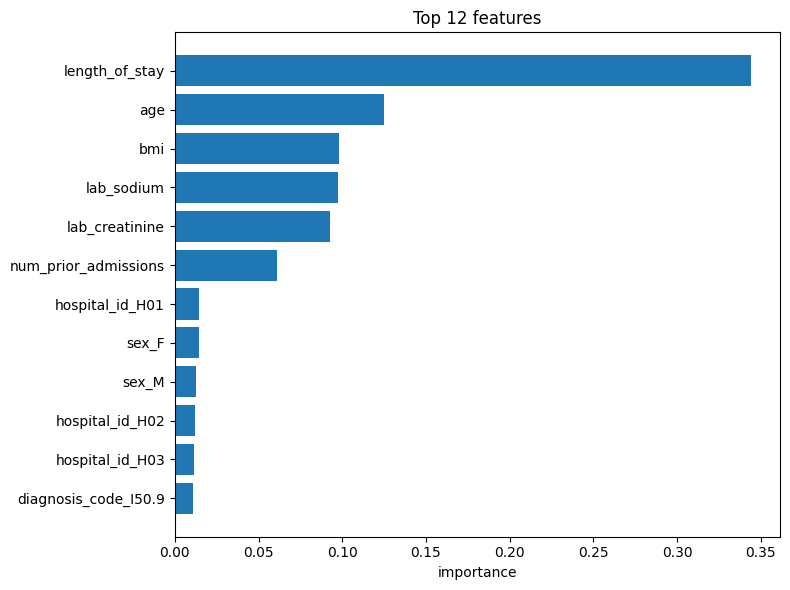

In [18]:
feature_names = list(X2.columns)
plot_feature_importance(rf, feature_names, top_n=12)
plt.show()

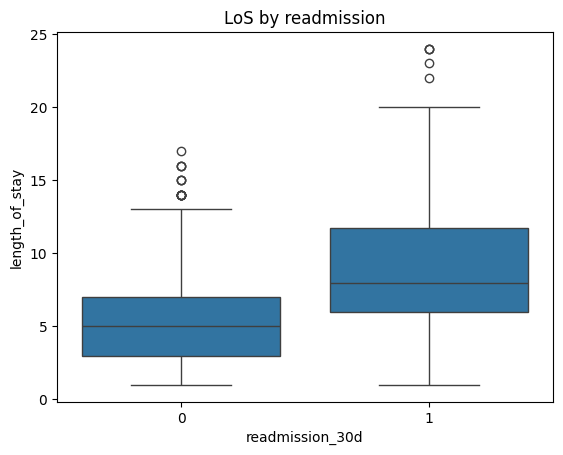

In [19]:
sns.boxplot(data=df, x='readmission_30d', y='length_of_stay')
plt.title('LoS by readmission')
plt.show()

In [20]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

kf = KFold(n_splits=5)   # no shuffle
scores = []
for tr_idx, va_idx in kf.split(X_all_scaled):
    X_tr = X_all_scaled[tr_idx]
    X_va = X_all_scaled[va_idx]
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)      # refit on already-scaled data
    X_va = sc.transform(X_va)
    m = LogisticRegression(max_iter=500)
    m.fit(X_tr, np.array(y_all)[tr_idx])
    scores.append(m.score(X_va, np.array(y_all)[va_idx]))
print('cv accuracies:', scores)
print('mean:', np.mean(scores))

cv accuracies: [0.8275, 0.8175, 0.825, 0.855, 0.815]
mean: 0.828


In [21]:
cv_res = cross_validate_model(LogisticRegression(max_iter=500), X_all_scaled, y_all, cv=5)
print(cv_res)

{'fold_scores': [np.float64(0.8052635770027073), np.float64(0.7452300785634118), np.float64(0.7217240963370994), np.float64(0.7896345140927185), np.float64(0.8050046685340803)], 'mean_score': 0.7733713869060035}


In [22]:
tmp2 = df_final.copy()
df_final_final = tmp2[tmp2['length_of_stay'] < 25]
print(df_final_final.shape)

(2000, 32)


In [23]:
# df_final_final.to_csv('out.csv')  # nah
# print(df_final_final['readmission_30d'].value_counts())
print(df_final_final['readmission_30d'].value_counts())
# print(df_final_final.head())

readmission_30d
0    1602
1     398
Name: count, dtype: int64


In [24]:
train_df, test_df = train_test_split_by_patient(df_final, test_size=0.2)
print(train_df.shape, test_df.shape)
# sanity check patient overlap (hopefully 0)
overlap = set(train_df['patient_id']) & set(test_df['patient_id'])
print('patient overlap:', len(overlap))

(1600, 32) (400, 32)
patient overlap: 106


In [25]:
print('Summary')
print('-------')
print('LogReg test acc: {:.3f}'.format(res['accuracy']))
print(f"LogReg AUC     : {res['roc_auc']:.3f}")
print('RF test acc    :', round(res_rf['accuracy'], 3))
print('RF AUC         :', round(res_rf['roc_auc'], 3))
# TODO: save model to disk


Summary
-------
LogReg test acc: 0.848
LogReg AUC     : 0.605
RF test acc    : 0.797
RF AUC         : 0.584


TODO: save model, write proper eval, turn this into a package